In [2]:
file_path = r"C:\Users\shash\OneDrive - purdue.edu\Pulse Rate Wearable Sensor\heartrate.data" 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
WINDOW_START = 1000
WINDOW_END = 10000

In [11]:
with open(file_path, "r") as f:
    lines = f.readlines()

In [12]:
for i, line in enumerate(lines):
    if "***End_of_Header***" in line:
        header_end = i
        break

In [13]:
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    skiprows=header_end + 1
)

print(df.head())

       Time       Current  Filtered  Current.1
0  0.000004  6.163054e-10       NaN        NaN
1  0.001004  6.159833e-10       NaN        NaN
2  0.002004  6.156612e-10       NaN        NaN
3  0.003004  6.159833e-10       NaN        NaN
4  0.004004  6.153392e-10       NaN        NaN


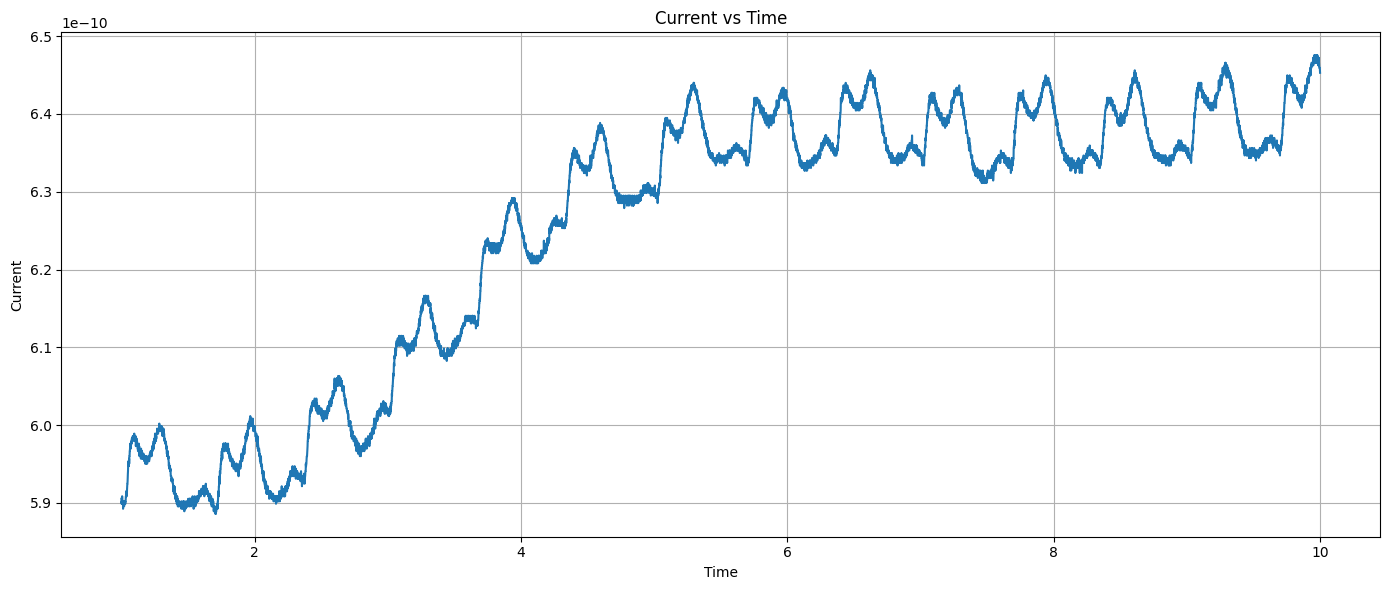

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))
plt.plot(df['Time'].iloc[WINDOW_START:WINDOW_END], df['Current'].iloc[WINDOW_START:WINDOW_END])
plt.xlabel('Time')
plt.ylabel('Current')
#plt.xticks(np.arange(1.0, 1.7, 0.02))
plt.title('Current vs Time')
plt.grid(True)
plt.tight_layout()
plt.show()

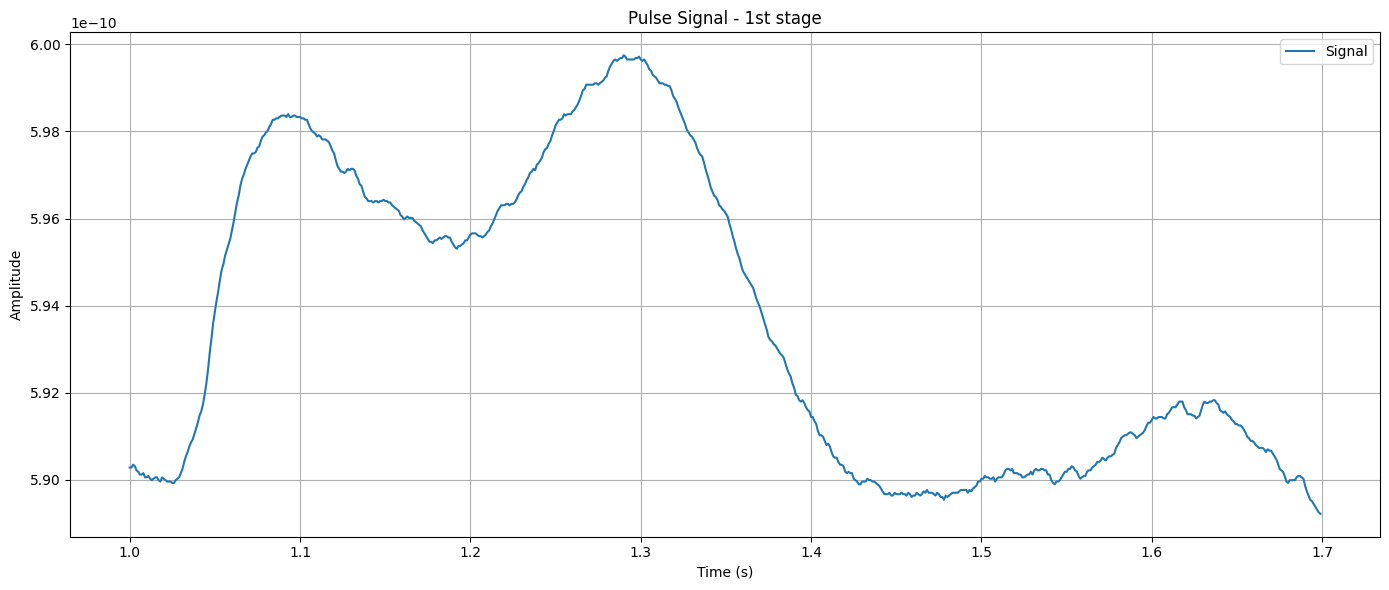

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== LOAD DATA =====================
time = df["Time"].values
current = df["Current"].values

dt = np.mean(np.diff(time))
fs = 1 / dt

# ===================== PARAMETERS =====================
SMOOTH_MS = 10


smooth_samples = int(SMOOTH_MS * fs / 1000)

# ===================== MORPHOLOGY SIGNAL =====================
signal = pd.Series(current).rolling(
    window=smooth_samples,
    center=True,
    min_periods=1
).mean().values

plt.figure(figsize=(14, 6))
plt.plot(time[WINDOW_START:WINDOW_END], signal[WINDOW_START:WINDOW_END], label="Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Pulse Signal - 1st stage")
#plt.xticks(np.arange(1.0, 1.7, 0.02))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


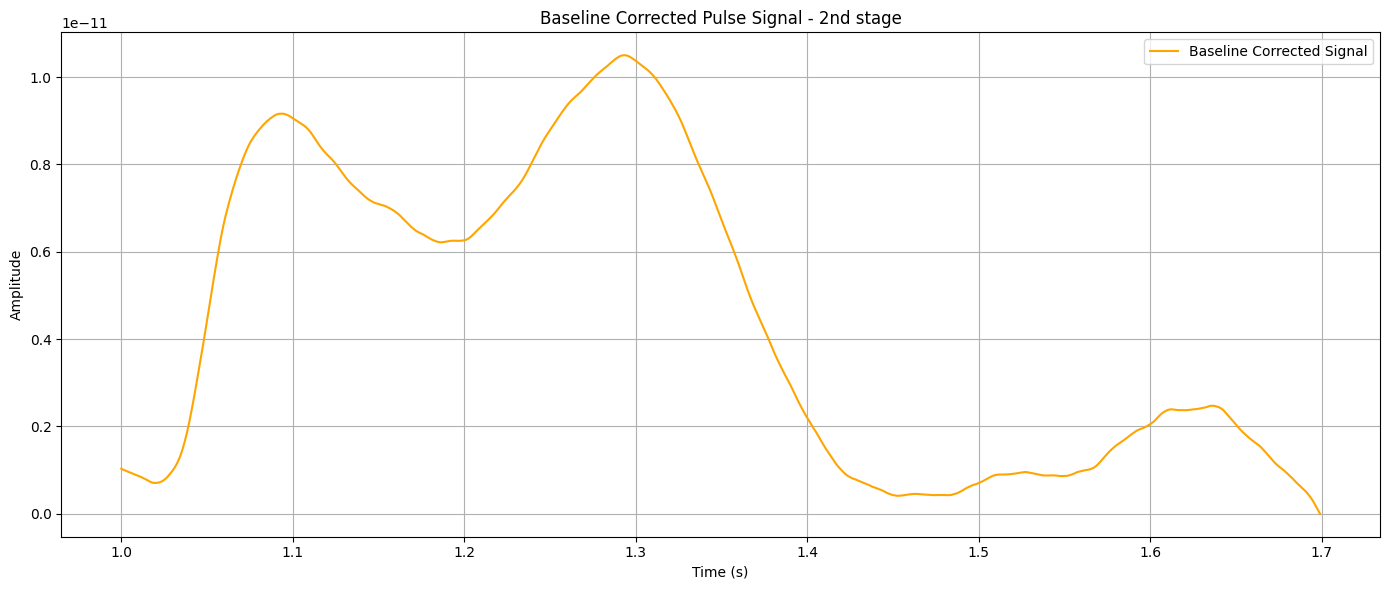

In [11]:
from scipy.signal import savgol_filter

# Smooth the signal
smooth = savgol_filter(signal, window_length=33, polyorder=3)

# Simple baseline correction: subtract the global minimum
# This shifts everything so the baseline is at 0
# Use a baseline from the selected window and clamp to >= 0
baseline_value = float(np.clip(np.min(smooth[WINDOW_START:WINDOW_END]), 0, None))
signal_bc = smooth

# Ensure no negative values
signal_bc[signal_bc < 0] = 0

signal = signal_bc - baseline_value

plt.figure(figsize=(14, 6))
plt.plot(time[WINDOW_START:WINDOW_END], signal[WINDOW_START:WINDOW_END], label="Baseline Corrected Signal", color='orange', linewidth=1.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Baseline Corrected Pulse Signal - 2nd stage")
#plt.xticks(np.arange(1.0, 1.7, 0.02))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Total peaks found: 274


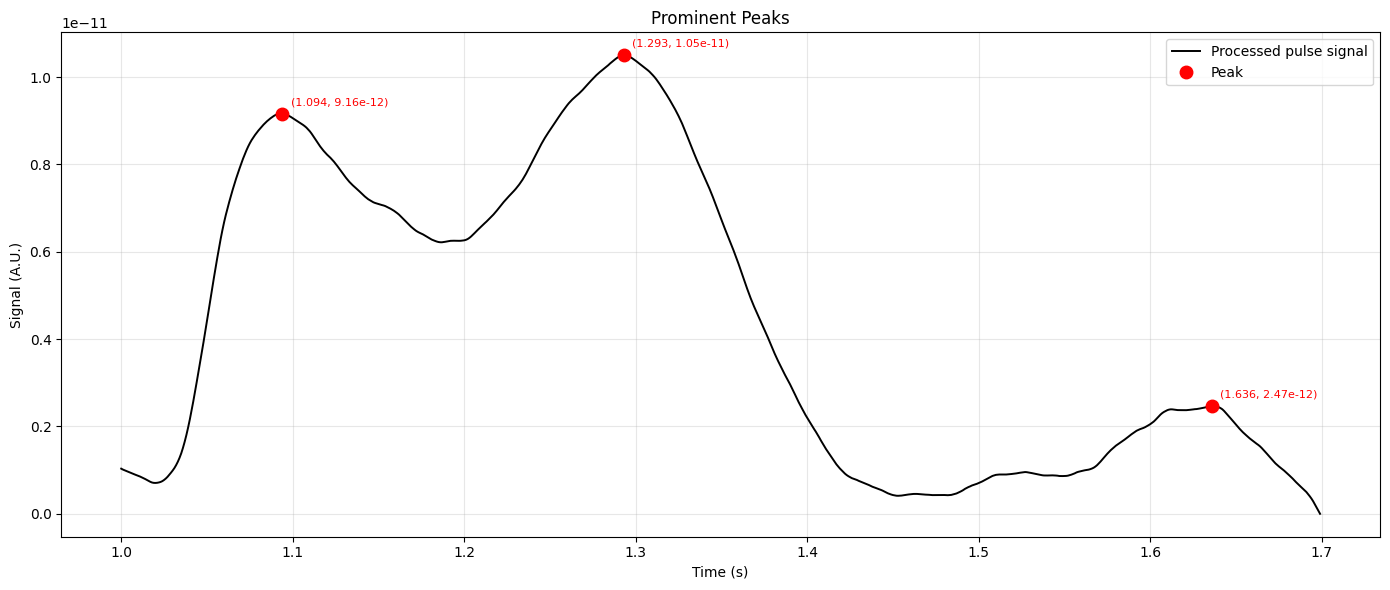

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ===================== FIND PEAKS WITH PROMINENCE =====================
signal_std = np.std(signal)
prominence_threshold = signal_std * 0.02

all_peaks, properties = find_peaks(
    signal,
    prominence=prominence_threshold,
    distance=int(fs * 0.12)
)

print(f"Total peaks found: {len(all_peaks)}")

plt.figure(figsize=(14, 6))
plt.plot(time[WINDOW_START:WINDOW_END], signal[WINDOW_START:WINDOW_END], label="Processed pulse signal", linewidth=1.4, color='black')
plt.plot(time[all_peaks[(all_peaks >= WINDOW_START) & (all_peaks < WINDOW_END)]], signal[all_peaks[(all_peaks >= WINDOW_START) & (all_peaks < WINDOW_END)]], 'ro', label="Peak", markersize=9)
mask = (all_peaks >= WINDOW_START) & (all_peaks < WINDOW_END)
for idx in all_peaks[mask]:
    x_val = time[idx]
    y_val = signal[idx]
    plt.annotate(f"({x_val:.3f}, {y_val:.2e})",
                 xy=(x_val, y_val),
                 xytext=(6, 6),
                 textcoords="offset points",
                 fontsize=8,
                 color='red')
plt.xlabel("Time (s)")
plt.ylabel("Signal (A.U.)")
plt.title("Prominent Peaks")
#plt.xticks(np.arange(1.0, 1.7, 0.02))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



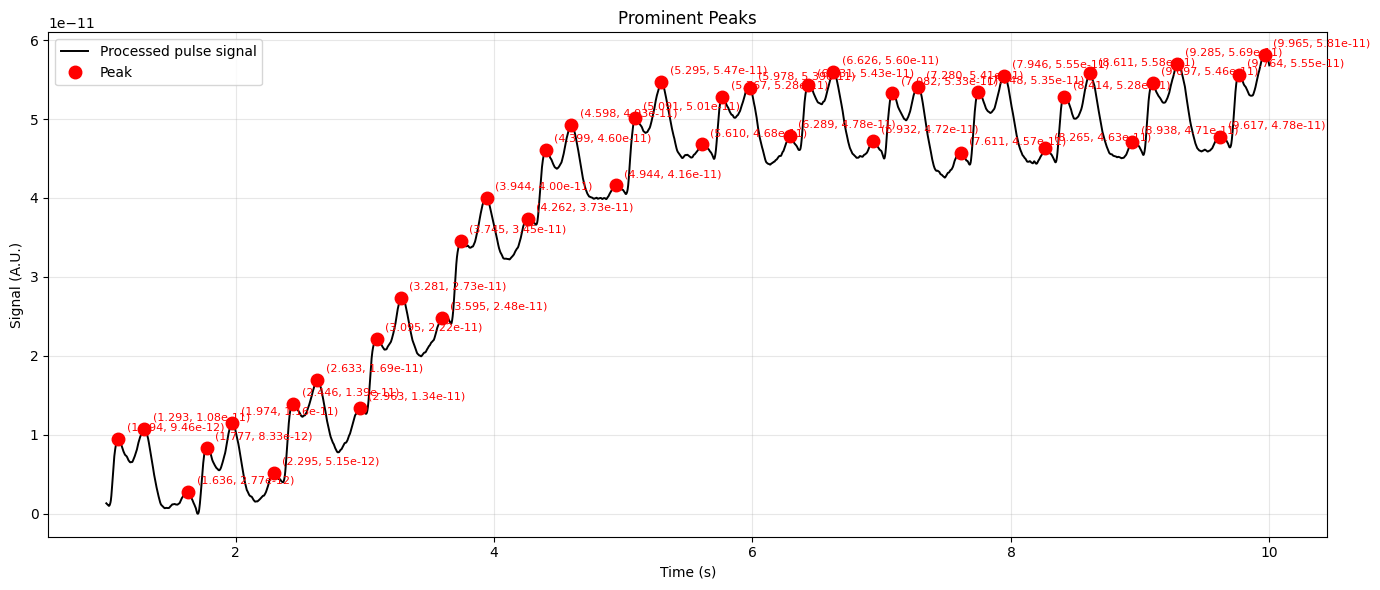

In [15]:
time = df["Time"].values
current = df["Current"].values

dt = np.mean(np.diff(time))
fs = 1 / dt
WINDOW_START = 1000
WINDOW_END = 10000
# ===================== PARAMETERS =====================
SMOOTH_MS = 10


smooth_samples = int(SMOOTH_MS * fs / 1000)

# ===================== MORPHOLOGY SIGNAL =====================
signal = pd.Series(current).rolling(
    window=smooth_samples,
    center=True,
    min_periods=1
).mean().values


from scipy.signal import savgol_filter

# Smooth the signal
smooth = savgol_filter(signal, window_length=33, polyorder=3)

# Simple baseline correction: subtract the global minimum
# This shifts everything so the baseline is at 0
# Use a baseline from the selected window and clamp to >= 0
baseline_value = float(np.clip(np.min(smooth[WINDOW_START:WINDOW_END]), 0, None))
signal_bc = smooth

# Ensure no negative values
signal_bc[signal_bc < 0] = 0

signal = signal_bc - baseline_value

from scipy.signal import find_peaks

# ===================== FIND PEAKS WITH PROMINENCE =====================
signal_std = np.std(signal)
prominence_threshold = signal_std * 0.02

all_peaks, properties = find_peaks(
    signal,
    prominence=prominence_threshold,
    distance=int(fs * 0.12)
)

plt.figure(figsize=(14, 6))
plt.plot(time[WINDOW_START:WINDOW_END], signal[WINDOW_START:WINDOW_END], label
="Processed pulse signal", linewidth=1.4, color='black')
plt.plot(time[all_peaks[(all_peaks >= WINDOW_START) & (all_peaks < WINDOW_END)]], signal[all_peaks[(all_peaks >= WINDOW_START) & (all_peaks < WINDOW_END)]], 'ro', label="Peak", markersize=9)
mask = (all_peaks >= WINDOW_START) & (all_peaks < WINDOW_END)
for idx in all_peaks[mask]:
    x_val = time[idx]
    y_val = signal[idx]
    plt.annotate(f"({x_val:.3f}, {y_val:.2e})",
                 xy=(x_val, y_val),
                 xytext=(6, 6),
                 textcoords="offset points",
                 fontsize=8,
                 color='red')
plt.xlabel("Time (s)")
plt.ylabel("Signal (A.U.)")
plt.title("Prominent Peaks")
#plt.xticks(np.arange(1.0, 1.7, 0.02))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Major peaks (P1, P2): 258
Minor peaks (P3): 16

Classified peaks:
P1: 27
P2: 27
P3: 0


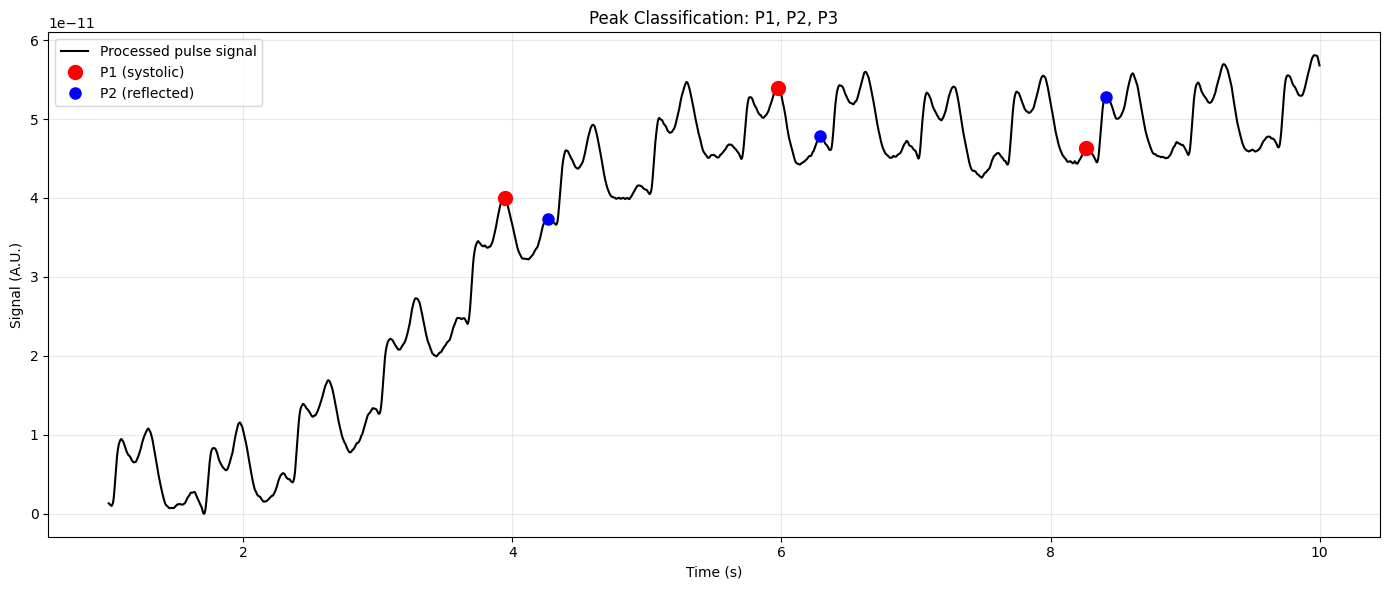

In [57]:

# ===================== SEPARATE MAJOR AND MINOR PEAKS BY AMPLITUDE =====================
# Get amplitudes of all detected peaks
peak_amplitudes = signal[all_peaks]
mean_amplitude = np.mean(peak_amplitudes)
std_amplitude = np.std(peak_amplitudes)

# P3 peaks are significantly smaller - typically < 50% of the mean major peak amplitude
# Major peaks (P1, P2) are larger
amplitude_threshold = mean_amplitude * 0.6

major_peaks = all_peaks[peak_amplitudes >= amplitude_threshold]
minor_peaks = all_peaks[peak_amplitudes < amplitude_threshold]

print(f"Major peaks (P1, P2): {len(major_peaks)}")
print(f"Minor peaks (P3): {len(minor_peaks)}")

# ===================== ASSIGN P1, P2, P3 WITHIN EACH BEAT =====================
P1 = []
P2 = []
P3 = []

# Combine and sort all peaks by index
all_sorted = np.sort(np.concatenate([major_peaks, minor_peaks]))

# Track expected P1 positions based on HR
min_beat_samples = int(fs * 60 / 240)  # Max HR
max_beat_samples = int(fs * 60 / 30)   # Min HR

beat_idx = 0
i = 0

while i < len(all_sorted):
    peak_idx = all_sorted[i]
    
    # Check if this is a major peak (potential P1)
    if peak_idx in major_peaks:
        p1_idx = peak_idx
        p1_amp = signal[p1_idx]
        
        # Look for P2 and P3 after this P1
        j = i + 1
        p2_idx = None
        p3_idx = None
        
        # Search within reasonable beat window
        search_end = p1_idx + max_beat_samples
        
        while j < len(all_sorted) and all_sorted[j] < search_end:
            candidate_idx = all_sorted[j]
            candidate_amp = signal[candidate_idx]
            
            # If we haven't found P2 yet, and this is a major peak, it's P2
            if p2_idx is None and candidate_idx in major_peaks:
                p2_idx = candidate_idx
                j += 1
                # Continue looking for P3 after P2
                continue
            
            # If we have P2 and find a minor peak, it's P3
            if p2_idx is not None and candidate_idx in minor_peaks and p3_idx is None:
                p3_idx = candidate_idx
                j += 1
                break
            
            j += 1
        
        # Accept beat if we found at least P1 and P2
        if p2_idx is not None:
            P1.append(p1_idx)
            P2.append(p2_idx)
            if p3_idx is not None:
                P3.append(p3_idx)
            
            # Move to next beat (skip past P2)
            i = j
        else:
            i += 1
    else:
        i += 1

P1 = np.array(P1)
P2 = np.array(P2)
P3 = np.array(P3)

print(f"\nClassified peaks:")
print(f"P1: {len(P1)}")
print(f"P2: {len(P2)}")
print(f"P3: {len(P3)}")

# ===================== PLOTTING =====================
plt.figure(figsize=(14, 6))
plt.plot(time[1000:10000], signal[1000:10000], label="Processed pulse signal", linewidth=1.5, color='black')
plt.plot(time[P1][(P1 >= 1000) & (P1 < 10000)], signal[P1][(P1 >= 1000) & (P1 < 10000)], 'ro', label="P1 (systolic)", markersize=10)
plt.plot(time[P2][(P2 >= 1000) & (P2 < 10000)], signal[P2][(P2 >= 1000) & (P2 < 10000)], 'bo', label="P2 (reflected)", markersize=8)
if len(P3) > 0:
    plt.plot(time[P3][(P3 >= 1000) & (P3 < 10000)], signal[P3][(P3 >= 1000) & (P3 < 10000)], 'g^', label="P3 (diastolic)", markersize=6)

plt.xlabel("Time (s)")
plt.ylabel("Signal (A.U.)")
plt.title("Peak Classification: P1, P2, P3")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Sampling rate: 1000.0 Hz
Calibration complete
Baseline mean: 6.478e-14
Noise std: 3.665e-12
Peak threshold: 5.562e-12
t=13.21s | BPM=45.2
t=14.52s | BPM=45.6
t=29.92s | BPM=3.9
t=32.95s | BPM=19.8
t=33.20s | BPM=239.0
t=35.16s | BPM=30.5
t=36.80s | BPM=36.7
t=47.51s | BPM=5.6


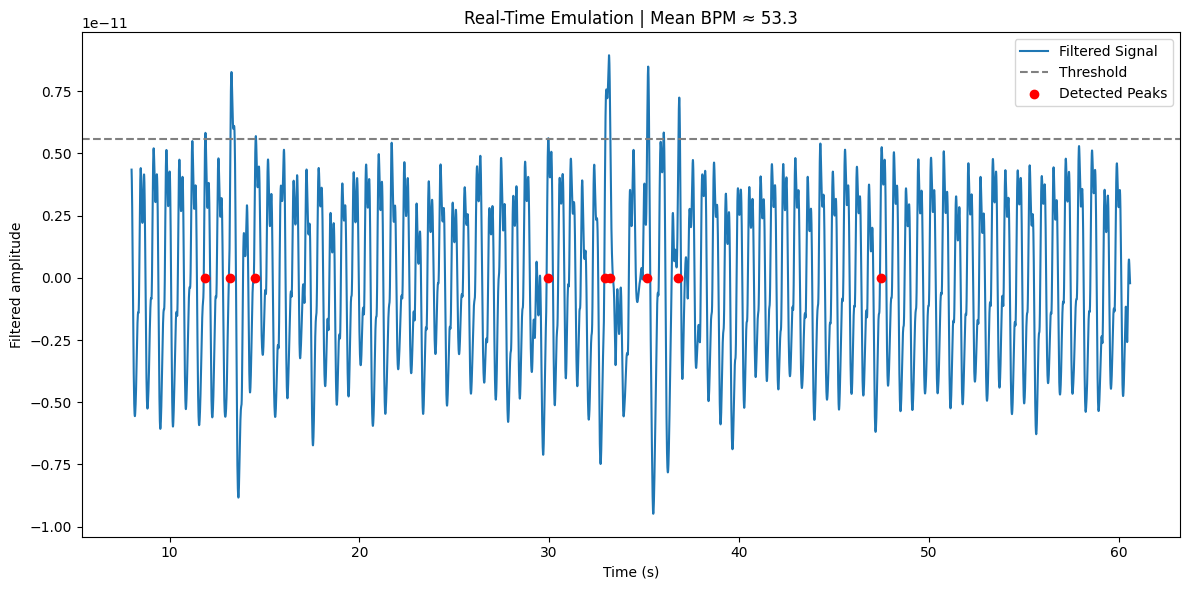

In [79]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, lfilter_zi

# =========================
# USER PARAMETERS
# =========================
CSV_FILE = "data.csv"
FS = 100                  # Hz (used if time column missing)
CALIBRATION_SEC = 8       # seconds
LOWCUT = 0.5              # Hz
HIGHCUT = 4.5             # Hz
REFRACTORY_SEC = 0.25     # seconds (max 240 BPM)
BASELINE_WIN_SEC = 1.5    # seconds

# =========================
# LOAD CSV
# =========================

if "Time" in df.columns:
    time_data = df["Time"].values
    signal = df["Current"].values
    FS = 1 / np.mean(np.diff(time_data))
else:
    signal = df.iloc[:, 0].values
    time_data = np.arange(len(signal)) / FS

print(f"Sampling rate: {FS:.1f} Hz")

# =========================
# BANDPASS FILTER (STATEFUL)
# =========================
nyq = 0.5 * FS
b, a = butter(2, [LOWCUT / nyq, HIGHCUT / nyq], btype="band")

zi = lfilter_zi(b, a)
filter_state = zi * signal[0]

def bandpass_step(x, state):
    y, state = lfilter(b, a, [x], zi=state)
    return y[0], state

# =========================
# CALIBRATION PHASE
# =========================
calib_samples = int(CALIBRATION_SEC * FS)
baseline_buffer = []
filtered_calib = []

for i in range(calib_samples):
    y, filter_state = bandpass_step(signal[i], filter_state)
    filtered_calib.append(y)
    baseline_buffer.append(y)

filtered_calib = np.array(filtered_calib)

# Baseline and noise estimates
baseline_mean = np.mean(filtered_calib)
noise_std = np.std(filtered_calib)

# Adaptive thresholds
PEAK_THRESHOLD = baseline_mean + 1.5 * noise_std
MIN_PEAK_HEIGHT = 0.5 * np.max(filtered_calib)

print("Calibration complete")
print(f"Baseline mean: {baseline_mean:.3e}")
print(f"Noise std: {noise_std:.3e}")
print(f"Peak threshold: {PEAK_THRESHOLD:.3e}")

# =========================
# REAL-TIME PROCESSING
# =========================
baseline_window = int(BASELINE_WIN_SEC * FS)
baseline_buffer = list(filtered_calib[-baseline_window:])

last_peak_time = None
bpm_history = []

filtered_rt = []
peak_times = []

for i in range(calib_samples, len(signal)):
    t = time_data[i]

    # --- Filter ---
    y, filter_state = bandpass_step(signal[i], filter_state)
    filtered_rt.append(y)

    # --- Update baseline ---
    baseline_buffer.append(y)
    if len(baseline_buffer) > baseline_window:
        baseline_buffer.pop(0)

    baseline = np.mean(baseline_buffer)
    signal_detrended = y - baseline

    # --- Peak detection ---
    is_peak = (
        signal_detrended > PEAK_THRESHOLD and
        (last_peak_time is None or t - last_peak_time > REFRACTORY_SEC)
    )

    if is_peak:
        peak_times.append(t)

        if last_peak_time is not None:
            ibi = t - last_peak_time
            bpm = 60 / ibi
            bpm_history.append(bpm)
            print(f"t={t:.2f}s | BPM={bpm:.1f}")

        last_peak_time = t

    # Optional: emulate real-time delay
    # time.sleep(1 / FS)

# =========================
# PLOTTING
# =========================
plt.figure(figsize=(12, 6))
plt.plot(time_data[calib_samples:], filtered_rt, label="Filtered Signal")
plt.axhline(PEAK_THRESHOLD, color="gray", linestyle="--", label="Threshold")
plt.scatter(peak_times,
            [0]*len(peak_times),
            color="red",
            label="Detected Peaks",
            zorder=3)

plt.xlabel("Time (s)")
plt.ylabel("Filtered amplitude")
plt.title(f"Real-Time Emulation | Mean BPM ≈ {np.mean(bpm_history):.1f}")
plt.legend()
plt.tight_layout()
plt.show()


In [89]:
import csv
import time

def realtime_csv_stream(csv_path, speed=1.0):
    """
    Yields (t, x) samples as if coming from real hardware.
    speed=1.0 → real time
    speed>1.0 → faster than real time
    """
    df_stream = df
    print(df_stream.columns)
    times = df_stream['Time'].values
    values = df_stream['Current'].values
    
    for i in range(1, len(times)):
        dt = (times[i] - times[i-1]) / speed
        if dt > 0:
            time.sleep(dt)
        yield times[i], values[i]


In [81]:
class SignalProcessor:
    def __init__(self, fs):
        self.fs = fs

        # Low-pass IIR (1st order)
        self.lpf_alpha = 2 * 3.1415 * 8 / (2 * 3.1415 * 8 + fs)
        self.lpf_state = 0.0

        # Baseline (slow EMA)
        self.baseline_alpha = 1 / (fs * 2.5)   # ~2.5 sec window
        self.baseline = 0.0

        # Noise tracking
        self.noise_alpha = 1 / (fs * 1.0)
        self.running_std = 1e-6

        # Peak detection memory
        self.x_prev2 = 0.0
        self.x_prev1 = 0.0
        self.last_peak_time = -1e9

        self.min_peak_spacing = 0.25  # seconds (240 BPM)

    def process_sample(self, t, x):
        # --- Low-pass filter ---
        self.lpf_state += self.lpf_alpha * (x - self.lpf_state)
        x_filt = self.lpf_state

        # --- Baseline estimation ---
        self.baseline += self.baseline_alpha * (x_filt - self.baseline)
        x_detrended = x_filt - self.baseline

        # --- Noise estimation ---
        self.running_std += self.noise_alpha * (
            abs(x_detrended) - self.running_std
        )

        # --- Artifact suppression (winsorization) ---
        clip = 5 * self.running_std
        if abs(x_detrended) > clip:
            x_detrended = clip * (1 if x_detrended > 0 else -1)

        # --- Peak detection (1-sample delay) ---
        peak = None
        if (self.x_prev2 < self.x_prev1 > x_detrended):
            if (t - self.last_peak_time) > self.min_peak_spacing:
                threshold = 2.5 * self.running_std
                if self.x_prev1 > threshold:
                    peak = (t, self.x_prev1)
                    self.last_peak_time = t

        # Shift history
        self.x_prev2 = self.x_prev1
        self.x_prev1 = x_detrended

        return x_detrended, peak


In [82]:
class BeatDetector:
    def __init__(self):
        self.state = "WAIT_P1"
        self.p1 = None
        self.p2 = None
        self.last_p1_time = None

        self.max_p1_p2 = 0.25
        self.max_p2_p3 = 0.30

    def process_peak(self, peak):
        t, amp = peak

        if self.state == "WAIT_P1":
            self.p1 = peak
            self.state = "WAIT_P2"

        elif self.state == "WAIT_P2":
            if t - self.p1[0] <= self.max_p1_p2:
                self.p2 = peak
                self.state = "WAIT_P3"
            else:
                self.state = "WAIT_P1"

        elif self.state == "WAIT_P3":
            if t - self.p2[0] <= self.max_p2_p3:
                p3 = peak
                hr = None
                if self.last_p1_time is not None:
                    dt = self.p1[0] - self.last_p1_time
                    if 0.25 < dt < 2.0:
                        hr = 60 / dt

                self.last_p1_time = self.p1[0]
                self.state = "WAIT_P1"
                return {
                    "P1": self.p1,
                    "P2": self.p2,
                    "P3": p3,
                    "HR": hr
                }
            else:
                self.state = "WAIT_P1"

        return None


In [90]:
fs = 250  # Hz
processor = SignalProcessor(fs)
detector = BeatDetector()

for t, x in realtime_csv_stream(file_path, speed=5.0):
    x_proc, peak = processor.process_sample(t, x)

    if peak:
        beat = detector.process_peak(peak)
        if beat:
            print(f"Beat @ {beat['P1'][0]:.2f}s | HR = {beat['HR']:.1f} BPM")


Index(['Time', 'Current', 'Filtered', 'Current.1'], dtype='str')
